# Tutorial 4: Brain Decoding Multivariate (BDM) Analysis

## Introduction

Brain Decoding Multivariate (BDM) analysis uses machine learning to predict experimental variables (e.g., stimulus properties) from EEG brain activity patterns. This reveals whether and when the brain encodes behaviorally relevant information.

### Key Concepts
- **Decoding**: Can a classifier learn to predict stimulus properties from brain activity?
- **Temporal Dynamics**: When is the stimulus information available in the EEG signal?
- **Generalization**: Does the decoding model work across different tasks or conditions?

### This Tutorial Covers
1. **Basic decoding**: Localizer task (subjects tracked repeated distractor images)
2. **Task decoding**: Main task (search for unique shape; distractor image as distractor)
3. **Trial averaging**: Trade-off between noise reduction and sample size
4. **Cross-task decoding**: Does distractor image representation transfer across tasks?

### What You'll Learn
- How to run multivariate decoding analysis
- How to interpret decoding results and timing
- How to optimize preprocessing for decoding
- When your brain data contains predictive information

## Setup: Imports and Data Loading

In [5]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os

# Add open_dvm to path
sys.path.insert(0, '/Users/dvm/Documents/DvM')

# Import analysis tools
import warnings
warnings.filterwarnings('ignore')

from open_dvm.analysis import BDM
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_bdm_timecourse

print("✓ All imports successful!")

✓ All imports successful!


In [6]:
# ============================================
# Configuration: Change these for your data
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 2

# Eye-tracking quality control
eye_dict = {
    'use_tracker': True,  # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,  # Threshold: 1 degree visual angle
    'viewing_dist': 70,  # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,  # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction window
}

# Load preprocessed data
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main', eye_dict
)

print(f'✓ Subject {sj} data loaded')
print(f'  • {len(epochs)} trials')
print(f'  • {epochs.info["nchan"]} channels')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')
print(f'\nBehavioral data columns:')
print(df.columns.tolist())

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
✓ Subject 2 data loaded
  • 2148 trials
  • 39 channels
  • Sampling rate: 512.0 Hz

Behavioral data columns:
['index', 'nr_trials', 'display_trigger', 'RT', 'subject_nr', 'block_cnt', 'block_type', 'correct', 'img_loc', 'target_loc', 'dist_cnd', 'dist_img', 'neut_shape', 'target_cnd', 'high_prob_dist', 'prev_target_loc', 'prev_img_loc', 'img_cnd', 'target_presence', 'distractor_presence']


In [7]:
# Explore the data structure
print("Block types available:", df['block_type'].unique())
print("\nLocalizer block - images:")
print(df[df['block_type'] == 'localizer']['dist_img'].value_counts().sort_index())
print("\nMain block - images:")
print(df[df['block_type'] == 'main']['dist_img'].value_counts().sort_index())

Block types available: <StringArray>
['localizer', 'main']
Length: 2, dtype: str

Localizer block - images:
dist_img
0    118
1    131
2    117
3    132
Name: count, dtype: int64

Main block - images:
dist_img
0    408
1    411
2    406
3    425
Name: count, dtype: int64


---

## Part 1: Localizer Task Decoding

The localizer task is specifically designed for decoding analysis - subjects tracked whether a distractor image repeated, creating a simple, high-signal task.

**Question**: Can we decode which distractor image was presented from EEG activity in the localizer task?

**Setup**:
- Decoder: Linear Discriminant Analysis (LDA)
- K-fold cross-validation: 10 folds
- Time window: 0-500 ms post-stimulus
- Metric: Area Under Curve (AUC)
- Variable decoded: Distractor image identity

In [9]:
# Initialize BDM for localizer decoding
bdm_localizer = BDM(
    sj=sj,
    epochs=epochs,
    df=df,
    to_decode='dist_img',    # Decode image identity
    baseline=(-0.2, 0),      # Baseline correction: -200 to 0 ms
    nr_folds=10,             # 10-fold cross-validation
    elec_oi='all',           # Use all electrodes
    data_type='raw',         # Time domain (not TF)
    downsample=128           # Downsample to 128 Hz (reduce computational load)
)

print(f"✓ BDM initialized")
print(f"  • Classifier: Linear Discriminant Analysis (LDA)")
print(f"  • Decoding: dist_img (image identity)")
print(f"  • Electrodes: {epochs.info['nchan']} channels")
print(f"  • K-fold: 10 folds")

✓ BDM initialized
  • Classifier: Linear Discriminant Analysis (LDA)
  • Decoding: dist_img (image identity)
  • Electrodes: 39 channels
  • K-fold: 10 folds


In [ ]:
# Run decoding on localizer task
output_localizer, _ = bdm_localizer.classify(
    cnds=dict(block_type=['localizer']),  # Select localizer trials
    window_oi=(-0.2, 0.5),                # Time window: -200 to 500 ms
    labels_oi='all',                      # Use all distractor images
    bdm_name='localizer',
    GAT=False,                            # Standard within-time decoding
    excl_factor=dict(img_loc=[8])         # Exclude trials where image not shown
)

print("✓ Localizer decoding complete")
print(f"  • Conditions: {list(output_localizer.keys())[:-1]}")
print(f"  • Time points: {output_localizer['info']['times'].shape}")

Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 10 out of 10 folds in run 1✓ Localizer decoding complete
  • Conditions: ['localizer', 'bdm_info']
  • Time points: (90,)


Times converted from seconds to milliseconds


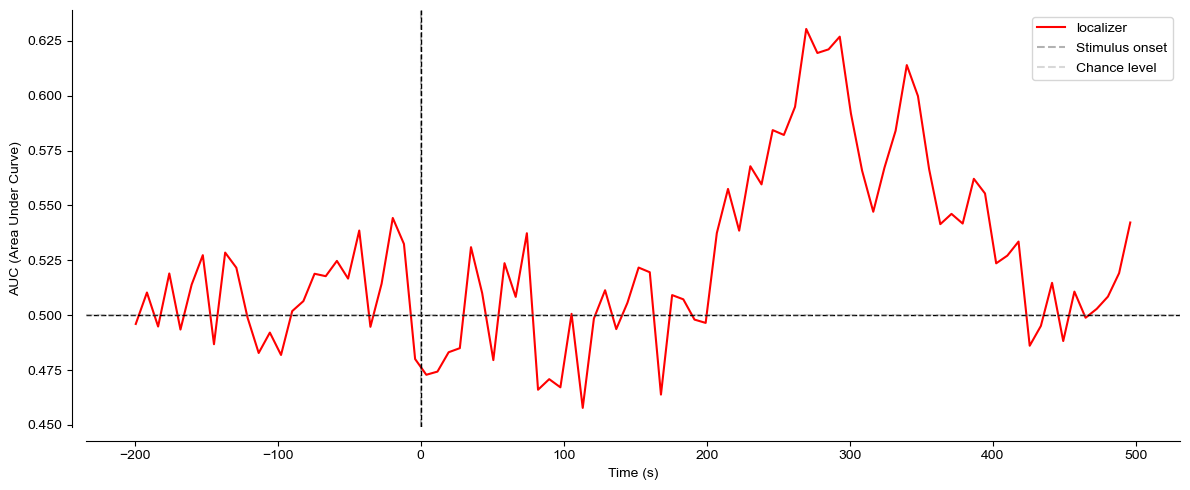


📊 Localizer Decoding Results:
  • Peak AUC: 0.630 at 0.270 s
  • Chance level: 0.500
  • Performance: 13.0% above chance


In [12]:
# Visualize localizer decoding results
plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    output_localizer,
    colors='red',
    stats=False,
    title='Localizer Task: Distractor Image Identity Decoding'
)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3, label='Stimulus onset')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Chance level')
plt.xlabel('Time (s)')
plt.ylabel('AUC (Area Under Curve)')
plt.legend()
plt.tight_layout()
plt.show()

# Extract key results
peak_auc = output_localizer['localizer']['dec_scores'].max()
peak_time = output_localizer['info']['times'][output_localizer['localizer']['dec_scores'].argmax()]
chance_level = 0.5  # AUC chance level is always 0.5
print(f"\n📊 Localizer Decoding Results:")
print(f"  • Peak AUC: {peak_auc:.3f} at {peak_time:.3f} s")
print(f"  • Chance level: {chance_level:.3f}")
print(f"  • Performance: {(peak_auc - chance_level) * 100:.1f}% above chance")

---

## Part 2: Compare Localizer vs Main Task

Now decode both conditions together. When running multiple conditions in one classify call, the BDM toolbox automatically equalizes label counts across conditions to ensure fair comparison.

In [14]:
# Decode both conditions in one call (automatically equalizes label counts)
output_combined, _ = bdm_localizer.classify(
    cnds=dict(block_type=['localizer', 'main']),  # Both conditions
    window_oi=(-0.2, 0.5),
    labels_oi='all',
    bdm_name=['localizer', 'main'],
    GAT=False,
    excl_factor=dict(img_loc=[8])         # Exclude trials where image not shown
)

print("✓ Decoding complete for both conditions")

Dropped 808 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 10 out of 10 folds in run 1
You are decoding main. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 10
Fold 10 out of 10 folds in run 1✓ Decoding complete for both conditions


Times converted from seconds to milliseconds


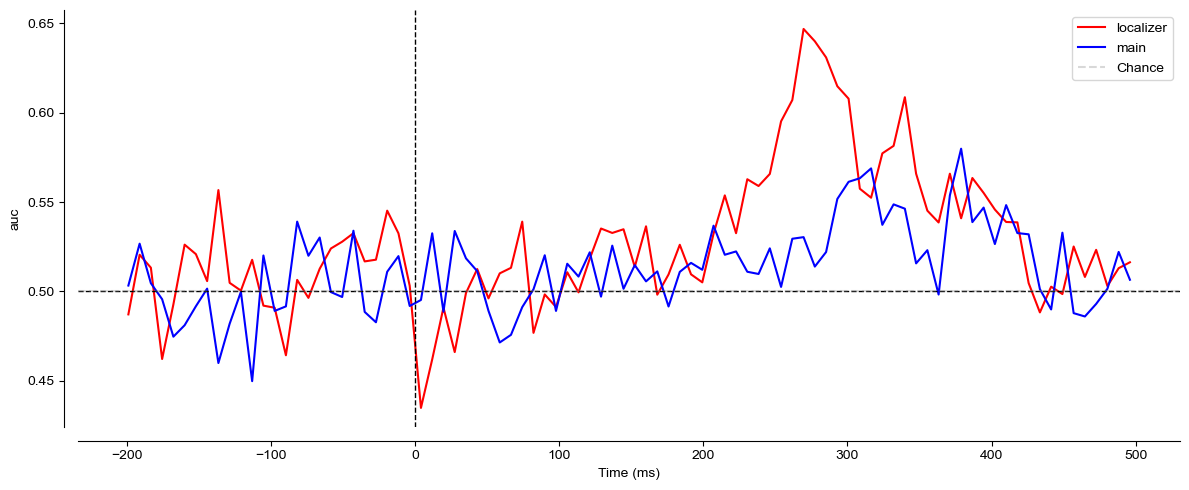


📊 Results:
  • Localizer peak AUC: 0.647
  • Main task peak AUC: 0.580
  • Difference: 0.067


In [16]:
# Visualize comparison
plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    output_combined,
    colors=['red', 'blue'],
    stats=False,
    title='Task Comparison: Localizer vs Main'
)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Chance')
plt.legend()
plt.tight_layout()
plt.show()

# Results
peak_auc_localizer = output_combined['localizer']['dec_scores'].max()
peak_auc_main = output_combined['main']['dec_scores'].max()
print(f"\n📊 Results:")
print(f"  • Localizer peak AUC: {peak_auc_localizer:.3f}")
print(f"  • Main task peak AUC: {peak_auc_main:.3f}")
print(f"  • Difference: {peak_auc_localizer - peak_auc_main:.3f}")

Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 10 out of 10 folds in run 1Times converted from seconds to milliseconds
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
Averaging across 2 trials
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 50

The difference between the highest and the lowest
number of observations per class is 7
Fold 10 out of 10 folds in run 1Times converted from seconds to milliseconds
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD

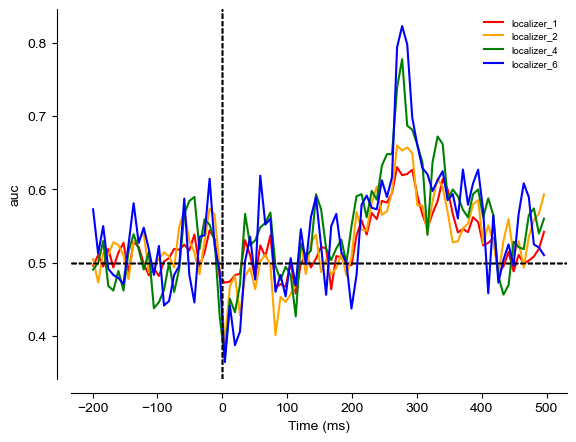

✓ Trial averaging analysis complete


In [21]:
# Test effect of trial averaging on localizer decoding
plt.close()

trial_avgs = [1, 2, 4, 6]
colors = ['red', 'orange', 'green', 'blue']

# Initialize once, will update avg_trials in loop
bdm_avg = BDM(
    sj=sj,
    epochs=epochs,
    df=df,
    to_decode='dist_img',
    baseline=(-0.2, 0),
    nr_folds=10,
    elec_oi='all',
    data_type='raw',
    downsample=128,
    avg_trials=1
)

for i, tr_avg in enumerate(trial_avgs):
    bdm_avg.avg_trials = tr_avg  # Update trial averaging
    
    output, _ = bdm_avg.classify(
        cnds=dict(block_type=['localizer']),
        window_oi=(-0.2, 0.5),
        labels_oi='all',
        bdm_name='localizer',
        GAT=False,
        excl_factor=dict(img_loc=[8])
    )
    
    # Rename key to track trial averaging
    output[f'localizer_{tr_avg}'] = output.pop('localizer')
    
    # Plot each trial averaging condition
    plot_bdm_timecourse(output, colors=[colors[i]], stats=False, 
                       title=f'Localizer: Trial Averaging = {tr_avg}')
plt.show()

print("✓ Trial averaging analysis complete")

### Trial Averaging Trade-Off

**Benefits of trial averaging:**
- Reduces noise from single-trial variability
- Typically increases peak AUC (smoother signal)
- More stable temporal dynamics

**Costs of trial averaging:**
- Reduced sample size for cross-validation training
- May lose fine temporal resolution
- Risk of overfitting with very small sample sizes

**Recommendation**: For this dataset, trial averaging of 2-4 often provides good balance between SNR and statistical power.

---

## Part 4: Cross-Task Decoding

**Research Question**: Does the neural representation of distractor image identity learned in the **localizer** (where it's task-relevant) generalize to the **main task** (where it's task-irrelevant)?

We'll train a decoder on localizer trials and test it on main task trials (without retraining).

In [23]:
# Initialize BDM with localizer as training set
bdm_cross = BDM(
    sj=sj,
    epochs=epochs.copy(),
    df=df.copy(),
    to_decode='dist_img',
    baseline=(-0.2, 0),
    nr_folds=10,
    elec_oi='all',
    data_type='raw',
    downsample=128
)

# Cross-task decoding: Train on localizer, test on main
# Format: {column: [[train_conditions], [test_conditions]]}
output_cross, _ = bdm_cross.classify(
    cnds=dict(block_type=[['localizer'], ['main']]),  # Train on localizer, test on main
    window_oi=(-0.2, 0.5),
    labels_oi='all',
    bdm_name='cross_task',
    GAT=False,
    excl_factor=dict(img_loc=[8])        # Exclude trials where image not shown
)

print("✓ Cross-task decoding complete")

Dropped 808 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

The difference between the highest and the lowest
number of observations per class is 15
Fold 1 out of 1 folds in run 1✓ Cross-task decoding complete


In [26]:
output_cross.keys()

dict_keys(['localizer_main', 'bdm_info', 'info'])

Times converted from seconds to milliseconds


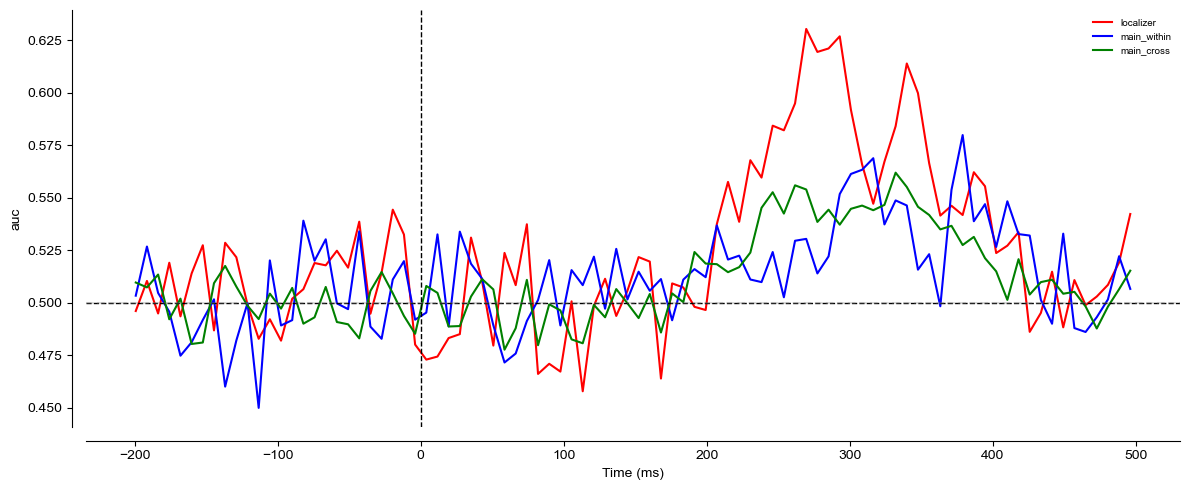

✓ Cross-task comparison complete


In [27]:
# Compare within-task vs. cross-task decoding
# Combine outputs for plotting
combined_cross = {
    'localizer': output_localizer['localizer'],
    'main_within': output_combined['main'],
    'main_cross': output_cross['localizer_main'],
    'info': output_localizer['info']
}

plt.figure(figsize=(12, 5))
plot_bdm_timecourse(combined_cross, colors=['red', 'blue', 'green'], stats=False,
                   title='Within-Task vs. Cross-Task Generalization')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Chance')
plt.tight_layout()
plt.show()

print("✓ Cross-task comparison complete")

---

## Summary

You've now completed a full decoding analysis pipeline:

1. ✅ **Localizer decoding**: Simple task, strong signal, clear timing
2. ✅ **Main task decoding**: Complex task, more realistic, weaker signal
3. ✅ **Trial averaging optimization**: Balance SNR vs. sample size
4. ✅ **Cross-task generalization**: Test whether representations are task-invariant

### Next Steps
- See `05_bdm_advanced.ipynb` for:
  - Generalization Across Time (GAT)
  - Time-frequency domain decoding
  - Classifier comparisons
  - Statistical testing
  - Cross-subject generalization